# Cargamos librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Cargamos inputs de preprocesamiento

In [4]:
df_model = pd.read_csv(
    "./artifacts/df_model.csv"
)

variables_modelo = pd.read_csv(
    "./artifacts/variables_modelo.csv"
)

diccionario_transformaciones = pd.read_csv(
    "./artifacts/diccionario_transformaciones.csv"
)

In [5]:
df_model.head()

,tenure,Contract,InternetService,PaymentMethod,TotalCharges,MonthlyCharges,PaperlessBilling,StreamingTV,StreamingMovies,Partner,Churn
0,1,0,1,0,29.85,29.85,1,1,1,1,0
1,34,1,1,1,1889.50,56.95,0,1,1,0,0
2,2,0,1,1,108.15,53.85,1,1,1,0,1
3,45,1,1,2,1840.75,42.30,0,1,1,0,0
4,2,0,2,0,151.65,70.70,1,1,1,0,1


# Obtenemos X e Y

In [7]:
X = df_model.drop(
    columns=["Churn"]
)

y = df_model["Churn"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(5625, 10)
(1407, 10)


# Modelos varios

In [14]:
modelo_logit = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logit.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [16]:
y_pred = modelo_logit.predict(X_test)

y_prob = modelo_logit.predict_proba(
    X_test
)[:,1]

In [17]:
auc = roc_auc_score(
    y_test,
    y_prob
)

gini = 2 * auc - 1

print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")

AUC: 0.8352
Gini: 0.6704


In [19]:
# Probabilidades train
y_prob_train = modelo_logit.predict_proba(
    X_train
)[:,1]

# Probabilidades test
y_prob_test = modelo_logit.predict_proba(
    X_test
)[:,1]


# TRAIN
auc_train = roc_auc_score(
    y_train,
    y_prob_train
)

gini_train = 2 * auc_train - 1


# TEST
auc_test = roc_auc_score(
    y_test,
    y_prob_test
)

gini_test = 2 * auc_test - 1


print("Resultados del modelo")
print("-" * 40)

print(f"AUC Train: {auc_train:.4f}")
print(f"Gini Train: {gini_train:.4f}")

print("-" * 40)

print(f"AUC Test: {auc_test:.4f}")
print(f"Gini Test: {gini_test:.4f}")

Resultados del modelo
----------------------------------------
AUC Train: 0.8449
Gini Train: 0.6899
----------------------------------------
AUC Test: 0.8352
Gini Test: 0.6704


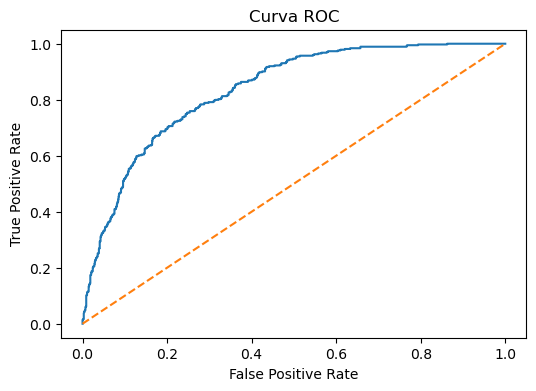

In [62]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(
    "artifacts/graficos/roc_logistica_inicial.png",
    bbox_inches="tight"
)
plt.show()

# Pesos de las variables

In [21]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente":
    modelo_logit.coef_[0]
})

In [23]:
coeficientes[
    "Coef_Cuadrado"
] = (
    coeficientes[
        "Coeficiente"
    ] ** 2
)

coeficientes[
    "Peso_Wald_%"
] = (
    coeficientes[
        "Coef_Cuadrado"
    ]
    /
    coeficientes[
        "Coef_Cuadrado"
    ].sum()
) * 100

coeficientes = (
    coeficientes
    .sort_values(
        "Peso_Wald_%",
        ascending=False
    )
)

coeficientes

,Variable,Coeficiente,Coef_Abs,Peso_%,Coef_Cuadrado,Peso_Wald_%
2,InternetService,1.136201,1.136201,34.200954,1.290952e+00,54.323567
1,Contract,-0.848913,0.848913,25.553257,7.206530e-01,30.325247
6,PaperlessBilling,0.358407,0.358407,10.788459,1.284554e-01,5.405435
7,StreamingTV,0.300813,0.300813,9.054832,9.048874e-02,3.807787
8,StreamingMovies,0.288958,0.288958,8.697978,8.349689e-02,3.513569
3,PaymentMethod,-0.226849,0.226849,6.828418,5.146049e-02,2.165469
9,Partner,-0.084170,0.084170,2.533607,7.084549e-03,0.298119
0,tenure,-0.058997,0.058997,1.775887,3.480682e-03,0.146468
5,MonthlyCharges,-0.018455,0.018455,0.555513,3.405821e-04,0.014332
4,TotalCharges,0.000369,0.000369,0.011095,1.358577e-07,0.000006


In [24]:
variables_top3 = [
    "InternetService",
    "Contract",
    "PaperlessBilling"
]

X_train_2 = X_train[
    variables_top3
]

X_test_2 = X_test[
    variables_top3
]

In [25]:
modelo_logit_2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logit_2.fit(
    X_train_2,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
y_prob_train_2 = (
    modelo_logit_2
    .predict_proba(X_train_2)
)[:,1]

y_prob_test_2 = (
    modelo_logit_2
    .predict_proba(X_test_2)
)[:,1]

In [27]:
auc_train_2 = roc_auc_score(
    y_train,
    y_prob_train_2
)

gini_train_2 = (
    2 * auc_train_2 - 1
)

auc_test_2 = roc_auc_score(
    y_test,
    y_prob_test_2
)

gini_test_2 = (
    2 * auc_test_2 - 1
)

print(
    f"AUC Train: {auc_train_2:.4f}"
)

print(
    f"Gini Train: {gini_train_2:.4f}"
)

print("-"*40)

print(
    f"AUC Test: {auc_test_2:.4f}"
)

print(
    f"Gini Test: {gini_test_2:.4f}"
)

AUC Train: 0.8097
Gini Train: 0.6195
----------------------------------------
AUC Test: 0.7941
Gini Test: 0.5882


# Comapramos ambos modelos 

In [28]:
comparacion_modelos = pd.DataFrame({

    "Modelo": [
        "Logística 1",
        "Logística 2"
    ],

    "Variables": [
        len(X_train.columns),
        len(variables_top3)
    ],

    "AUC_Train": [
        auc_train,
        auc_train_2
    ],

    "Gini_Train": [
        gini_train,
        gini_train_2
    ],

    "AUC_Test": [
        auc_test,
        auc_test_2
    ],

    "Gini_Test": [
        gini_test,
        gini_test_2
    ]
})

comparacion_modelos

,Modelo,Variables,AUC_Train,Gini_Train,AUC_Test,Gini_Test
0,Logística 1,10,0.844929,0.689858,0.83518,0.670359
1,Logística 2,3,0.809742,0.619484,0.79410,0.588199


El modelo peirde mucho gini, eso que no sumaban en importancia

# Bucle para ver hasta q variable quedarnos 

In [29]:
ranking_variables = coeficientes[
    "Variable"
].tolist()

ranking_variables

['InternetService',
 'Contract',
 'PaperlessBilling',
 'StreamingTV',
 'StreamingMovies',
 'PaymentMethod',
 'Partner',
 'tenure',
 'MonthlyCharges',
 'TotalCharges']

In [30]:
resultados_modelos = []

for n_vars in range(10, 2, -1):
    
    variables_modelo_loop = (
        ranking_variables[:n_vars]
    )
    
    X_train_loop = X_train[
        variables_modelo_loop
    ]
    
    X_test_loop = X_test[
        variables_modelo_loop
    ]
    
    
    # Modelo
    modelo_loop = LogisticRegression(
        max_iter=1000,
        random_state=42
    )
    
    modelo_loop.fit(
        X_train_loop,
        y_train
    )
    
    
    # Predicciones
    y_prob_train_loop = (
        modelo_loop
        .predict_proba(X_train_loop)
    )[:,1]
    
    y_prob_test_loop = (
        modelo_loop
        .predict_proba(X_test_loop)
    )[:,1]
    
    
    # Métricas
    auc_train_loop = roc_auc_score(
        y_train,
        y_prob_train_loop
    )
    
    gini_train_loop = (
        2 * auc_train_loop - 1
    )
    
    auc_test_loop = roc_auc_score(
        y_test,
        y_prob_test_loop
    )
    
    gini_test_loop = (
        2 * auc_test_loop - 1
    )
    
    
    resultados_modelos.append({
        "N_Variables":
        n_vars,
        
        "Variables":
        ", ".join(
            variables_modelo_loop
        ),
        
        "Gini_Train":
        round(
            gini_train_loop,
            4
        ),
        
        "Gini_Test":
        round(
            gini_test_loop,
            4
        )
    })

In [31]:
tabla_modelos = pd.DataFrame(
    resultados_modelos
)

tabla_modelos

,N_Variables,Variables,Gini_Train,Gini_Test
0,10,"InternetService, Contract, PaperlessBilling, S...",0.6898,0.6704
1,9,"InternetService, Contract, PaperlessBilling, S...",0.6833,0.6657
2,8,"InternetService, Contract, PaperlessBilling, S...",0.6819,0.6647
3,7,"InternetService, Contract, PaperlessBilling, S...",0.6471,0.6060
4,6,"InternetService, Contract, PaperlessBilling, S...",0.6399,0.6043
5,5,"InternetService, Contract, PaperlessBilling, S...",0.6241,0.5828
6,4,"InternetService, Contract, PaperlessBilling, S...",0.6237,0.5828
7,3,"InternetService, Contract, PaperlessBilling",0.6195,0.5882


hay un salto fuerte al quyitar la 4ta variables que es "PArtner" entonces qudemos con 8 variables como ejercicio

# Ahora comparando ocn otro algoritmo 

In [32]:
variables_finales = ranking_variables[:8]

variables_finales

['InternetService',
 'Contract',
 'PaperlessBilling',
 'StreamingTV',
 'StreamingMovies',
 'PaymentMethod',
 'Partner',
 'tenure']

In [33]:
X_train_final = X_train[
    variables_finales
]

X_test_final = X_test[
    variables_finales
]

In [36]:
from xgboost import XGBClassifier

In [37]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

modelo_xgb.fit(
    X_train_final,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_prob_train_xgb = (
    modelo_xgb
    .predict_proba(X_train_final)
)[:,1]

y_prob_test_xgb = (
    modelo_xgb
    .predict_proba(X_test_final)
)[:,1]

In [39]:
auc_train_xgb = roc_auc_score(
    y_train,
    y_prob_train_xgb
)

gini_train_xgb = (
    2 * auc_train_xgb - 1
)

auc_test_xgb = roc_auc_score(
    y_test,
    y_prob_test_xgb
)

gini_test_xgb = (
    2 * auc_test_xgb - 1
)

print(
    f"Gini Train XGB: {gini_train_xgb:.4f}"
)

print(
    f"Gini Test XGB: {gini_test_xgb:.4f}"
)

Gini Train XGB: 0.7140
Gini Test XGB: 0.6812


In [44]:
importancia_xgb = pd.DataFrame({
    "Variable":
    X_train_final.columns,
    
    "Gain":
    modelo_xgb.feature_importances_
})

In [45]:
importancia_xgb[
    "Gain_%"
] = (
    importancia_xgb[
        "Gain"
    ]
    /
    importancia_xgb[
        "Gain"
    ].sum()
) * 100

In [46]:
importancia_xgb = (
    importancia_xgb
    .sort_values(
        "Gain_%",
        ascending=False
    )
)

importancia_xgb

,Variable,Gain,Gain_%
1,Contract,0.565696,56.569607
0,InternetService,0.131684,13.168448
7,tenure,0.077428,7.742811
5,PaymentMethod,0.074730,7.473022
4,StreamingMovies,0.049792,4.979171
2,PaperlessBilling,0.047326,4.732617
3,StreamingTV,0.045249,4.524897
6,Partner,0.008094,0.809426


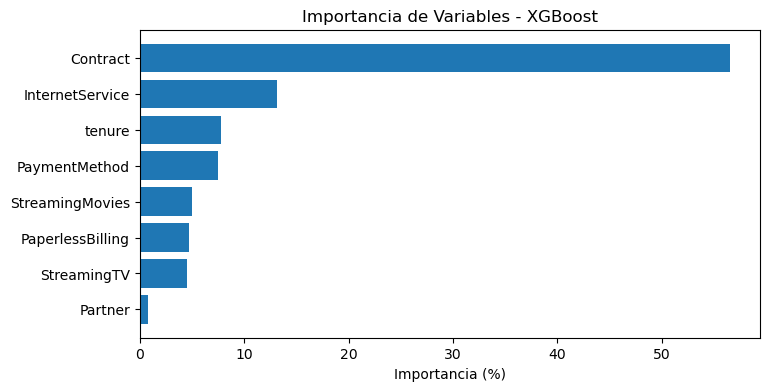

In [61]:
plt.figure(figsize=(8,4))

plt.barh(
    importancia_xgb[
        "Variable"
    ],
    
    importancia_xgb[
        "Gain_%"
    ]
)

plt.title(
    "Importancia de Variables - XGBoost"
)

plt.xlabel(
    "Importancia (%)"
)

plt.gca().invert_yaxis()


plt.savefig(
    "artifacts/graficos/importancia_xgb.png",
    bbox_inches="tight"
)

plt.show()

In [52]:
variables_finales = ranking_variables[:8]

variables_finales

['InternetService',
 'Contract',
 'PaperlessBilling',
 'StreamingTV',
 'StreamingMovies',
 'PaymentMethod',
 'Partner',
 'tenure']

In [53]:
X_train_final = X_train[
    variables_finales
]

X_test_final = X_test[
    variables_finales
]

In [54]:
modelo_logistico_final = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_logistico_final.fit(
    X_train_final,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
y_prob_train_final = (
    modelo_logistico_final
    .predict_proba(X_train_final)
)[:,1]

y_prob_test_final = (
    modelo_logistico_final
    .predict_proba(X_test_final)
)[:,1]

In [56]:
auc_train_final = roc_auc_score(
    y_train,
    y_prob_train_final
)

gini_train_final = (
    2 * auc_train_final - 1
)

auc_test_final = roc_auc_score(
    y_test,
    y_prob_test_final
)

gini_test_final = (
    2 * auc_test_final - 1
)

In [57]:
comparacion_final = pd.DataFrame({

    "Modelo": [
        "Logistica_10",
        "Logistica_8",
        "XGBoost_8"
    ],

    "N_Variables": [
        10,
        8,
        8
    ],

    "AUC_Train": [
        auc_train,
        auc_train_final,
        auc_train_xgb
    ],

    "Gini_Train": [
        gini_train,
        gini_train_final,
        gini_train_xgb
    ],

    "AUC_Test": [
        auc_test,
        auc_test_final,
        auc_test_xgb
    ],

    "Gini_Test": [
        gini_test,
        gini_test_final,
        gini_test_xgb
    ]
})

comparacion_final

,Modelo,N_Variables,AUC_Train,Gini_Train,AUC_Test,Gini_Test
0,Logistica_10,10,0.844929,0.689858,0.835180,0.670359
1,Logistica_8,8,0.840955,0.681909,0.832334,0.664668
2,XGBoost_8,8,0.856988,0.713976,0.840622,0.681244


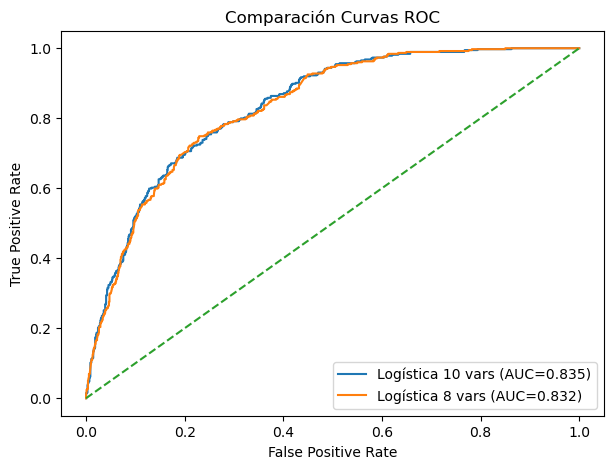

In [63]:
# ROC modelo 10 variables
fpr_10, tpr_10, _ = roc_curve(
    y_test,
    y_prob
)

# ROC modelo final 8 variables
fpr_8, tpr_8, _ = roc_curve(
    y_test,
    y_prob_test_final
)

plt.figure(figsize=(7,5))

# Modelo 10
plt.plot(
    fpr_10,
    tpr_10,
    label=f"Logística 10 vars (AUC={auc_test:.3f})"
)

# Modelo 8
plt.plot(
    fpr_8,
    tpr_8,
    label=f"Logística 8 vars (AUC={auc_test_final:.3f})"
)

# Línea aleatoria
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title(
    "Comparación Curvas ROC"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.savefig(
    "artifacts/graficos/comparacion_roc_logistica.png",
    bbox_inches="tight"
)

plt.show()

In [48]:
import os

os.makedirs(
    "artifacts/tablas",
    exist_ok=True
)

os.makedirs(
    "artifacts/graficos",
    exist_ok=True
)

os.makedirs(
    "artifacts/modelos",
    exist_ok=True
)

In [58]:
tabla_modelos.to_csv(
    "artifacts/tablas/seleccion_variables.csv",
    index=False
)

coeficientes.to_csv(
    "artifacts/tablas/coeficientes_logistica.csv",
    index=False
)

importancia_xgb.to_csv(
    "artifacts/tablas/importancia_xgb.csv",
    index=False
)

comparacion_modelos.to_csv(
    "artifacts/tablas/comparacion_modelos.csv",
    index=False
)

comparacion_final.to_csv(
    "artifacts/tablas/comparacion_modelos_final.csv",
    index=False
)

In [59]:
import joblib

joblib.dump(
    modelo_logit,
    "artifacts/modelos/modelo_logistico.pkl"
)

joblib.dump(
    modelo_logistico_final,
    "artifacts/modelos/modelo_logistico_final.pkl"
)

joblib.dump(
    modelo_xgb,
    "artifacts/modelos/modelo_xgb.pkl"
)

['artifacts/modelos/modelo_xgb.pkl']